In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [12]:
df = pd.read_csv("projetos-de-pesquisa-limpo.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21382 entries, 0 to 21381
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              21382 non-null  int64  
 1   id_projeto_pesquisa     21382 non-null  int64  
 2   codigo_projeto          21382 non-null  object 
 3   titulo                  21382 non-null  object 
 4   palavras_chave          21130 non-null  object 
 5   id_projeto              21382 non-null  int64  
 6   ano                     21382 non-null  int64  
 7   data_inicio             21351 non-null  object 
 8   data_fim                21121 non-null  object 
 9   situacao                21382 non-null  object 
 10  tipo_projeto            21382 non-null  object 
 11  categoria_projeto       21382 non-null  object 
 12  id_unidade              21382 non-null  int64  
 13  unidade                 21382 non-null  object 
 14  id_grupo_pesquisa       17636 non-null

In [13]:
df['data_inicio'] = pd.to_datetime(df['data_inicio'], errors='coerce')
df['data_fim'] = pd.to_datetime(df['data_fim'], errors='coerce')

df['ano_inicio'] = df['data_inicio'].dt.year
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21382 entries, 0 to 21381
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Unnamed: 0              21382 non-null  int64         
 1   id_projeto_pesquisa     21382 non-null  int64         
 2   codigo_projeto          21382 non-null  object        
 3   titulo                  21382 non-null  object        
 4   palavras_chave          21130 non-null  object        
 5   id_projeto              21382 non-null  int64         
 6   ano                     21382 non-null  int64         
 7   data_inicio             21351 non-null  datetime64[ns]
 8   data_fim                21121 non-null  datetime64[ns]
 9   situacao                21382 non-null  object        
 10  tipo_projeto            21382 non-null  object        
 11  categoria_projeto       21382 non-null  object        
 12  id_unidade              21382 non-null  int64 

In [15]:
print("ESTATÍSTICAS GERAIS")
print(f"Total de projetos: {len(df):,}")
print(f"Período coberto: {df['ano_inicio'].min()} - {df['ano_inicio'].max()}")
print(f"Unidades acadêmicas distintas: {df['unidade'].nunique()}")
print(f"Áreas do conhecimento distintas: {df['area_conhecimento_cnpq'].nunique()}")
print(f"Tipos de projeto: {df['tipo_projeto'].value_counts().to_dict()}")
print(f"Situações dos projetos: {df['situacao'].value_counts().to_dict()}")

ESTATÍSTICAS GERAIS
Total de projetos: 21,382
Período coberto: 1998.0 - 2025.0
Unidades acadêmicas distintas: 264
Áreas do conhecimento distintas: 922
Tipos de projeto: {'INTERNO': 16244, 'EXTERNO': 5138}
Situações dos projetos: {'FINALIZADO': 9897, 'RENOVADO': 7506, 'EM EXECUÇÃO': 3979}


QUANTIDADE DE PROJETOS POR ANO DE INICIO


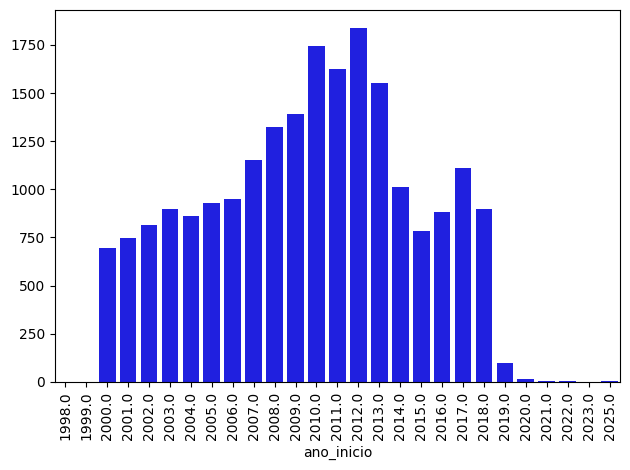

In [22]:
print("QUANTIDADE DE PROJETOS POR ANO DE INICIO")
projetos_por_ano = df['ano_inicio'].value_counts().sort_index()
sns.barplot(x=projetos_por_ano.index, y=projetos_por_ano.values, color='blue')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [24]:
print("ESTATÍSTICAS POR ANO DE INICIO")
print(f"Ano com mais projetos: {projetos_por_ano.idxmax()} ({projetos_por_ano.max()} projetos)")
print(f"Ano com menos projetos: {projetos_por_ano.idxmin()} ({projetos_por_ano.min()} projetos)")
print(f"Média de projetos por ano: {projetos_por_ano.mean():.1f}")

ESTATÍSTICAS POR ANO DE INICIO
Ano com mais projetos: 2012.0 (1839 projetos)
Ano com menos projetos: 1998.0 (1 projetos)
Média de projetos por ano: 790.8


In [28]:
print("15 UNIDADES ACADÊMICAS COM MAIS PROJETOS")
unidades_top = df['unidade'].value_counts().head(15)
print(unidades_top)

15 UNIDADES ACADÊMICAS COM MAIS PROJETOS
unidade
CENTRO DE CIÊNCIAS DA SAÚDE                   1319
CT VICE-DIRETORIA                             1240
CENTRO DE CIÊNCIAS HUMANAS, LETRAS E ARTES    1080
CENTRO DE CIÊNCIAS EXATAS E DA TERRA          1057
CENTRO DE BIOCIÊNCIAS                          934
CENTRO DE CIÊNCIAS SOCIAIS APLICADAS           812
ESCOLA AGRÍCOLA DE JUNDIAÍ                     579
ESCOLA DE CIÊNCIAS E TECNOLOGIA                553
DEPARTAMENTO DE ODONTOLOGIA                    537
DEPARTAMENTO DE ENGENHARIA QUIMICA             490
DEPARTAMENTO DE ENFERMAGEM                     484
DEPARTAMENTO DE FISIOTERAPIA                   366
DEPARTAMENTO DE FARMACIA                       366
DEPARTAMENTO DE PSICOLOGIA                     352
DEPARTAMENTO DE LETRAS                         352
Name: count, dtype: int64


In [29]:
print("15 ÁREAS DO CONHECIMENTO MAIS PESQUISADAS")
areas_top = df['area_conhecimento_cnpq'].value_counts().head(15)
print(areas_top)

15 ÁREAS DO CONHECIMENTO MAIS PESQUISADAS
area_conhecimento_cnpq
Administração de Empresas                   695
Fisioterapia e Terapia Ocupacional          441
Saúde Pública                               350
Enfermagem em Saúde Coletiva                326
Clínica Odontológica                        319
Educação Física                             259
Enfermagem em Saúde do Adulto e do Idoso    231
Avaliação e analises toxicológicas          223
Farmacotécnica e tecnologia farmacêutica    217
Saúde Materno-Infantil                      212
Geologia                                    200
Lingüística Aplicada                        193
Sistemas de Computação                      185
Epidemiologia                               162
Administração                               159
Name: count, dtype: int64


In [ ]:
print("ESTATÍSTICAS DE DURAÇÃO DOS PROJETOS")
df['duracao_dias'] = (df['data_fim'] - df['data_inicio']).dt.days
duracao_valida = df[df['duracao_dias'] > 0]['duracao_dias']
print(f"Duração média dos projetos: {duracao_valida.mean():.1f} dias")
print(f"Duração mediana dos projetos: {duracao_valida.median():.1f} dias")

ESTATÍSTICA DE DURAÇÃO DOS PROJETOS
Duração média dos projetos: 578.3 dias
Duração mediana dos projetos: 365.0 dias


In [31]:
print("PROJETOS POR SITUAÇÃO")
print(df['situacao'].value_counts())

PROJETOS POR SITUAÇÃO
situacao
FINALIZADO     9897
RENOVADO       7506
EM EXECUÇÃO    3979
Name: count, dtype: int64


In [32]:
print("PROJETOS POR TIPO")
print(df['tipo_projeto'].value_counts())

PROJETOS POR TIPO
tipo_projeto
INTERNO    16244
EXTERNO     5138
Name: count, dtype: int64
